<a href="https://colab.research.google.com/github/Gloou-ui/NM/blob/main/%D0%9B%D0%914_%D0%9B%D0%B8%D1%82%D0%B2%D0%B8%D0%BD_%D0%9C%D0%B8%D1%80%D0%BE%D1%81%D0%BB%D0%B0%D0%B2_%D0%A4%D0%86%D0%A23_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
  r2_score,
  mean_absolute_error,
  mean_squared_error,
  mean_absolute_percentage_error,
)

## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [4]:


!wget -q -O car_price.zip https://www.kaggle.com/api/v1/datasets/download/hellbuoy/car-price-prediction

!unzip -o car_price.zip -d car_data

df = pd.read_csv("car_data/CarPrice_Assignment.csv")

print("Кількість об'єктів:", df.shape[0])
print("Кількість ознак:", df.shape[1])

print("\nНазви стовпців:")
print(df.columns.tolist())

print("\nТипи даних:")
print(df.dtypes)

print("\nПерші 5 рядків:")
display(df.head())

print("\nОсновні статистичні характеристики:")
display(df.describe())

Archive:  car_price.zip
  inflating: car_data/CarPrice_Assignment.csv  
  inflating: car_data/Data Dictionary - carprices.xlsx  
Кількість об'єктів: 205
Кількість ознак: 26

Назви стовпців:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Типи даних:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
engi

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0



Основні статистичні характеристики:


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [5]:
print("Пропущені значення:")
print(df.isnull().sum())

print("\nКількість повних дублікатів:")
print(df.duplicated().sum())

print("\nКількість унікальних значень:")
print(df.nunique())

Пропущені значення:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Кількість повних дублікатів:
0

Кількість унікальних значень:
car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          

## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [6]:
car_ids = df["car_ID"].copy()

X = df.drop(columns=["car_ID", "price"])
y = df["price"]

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

Розмір X: (205, 24)
Розмір y: (205,)


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


Числові ознаки:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

Коефіцієнти асиметрії:


,skewness
compressionratio,2.610862
enginesize,1.947655
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997
symboling,0.211072


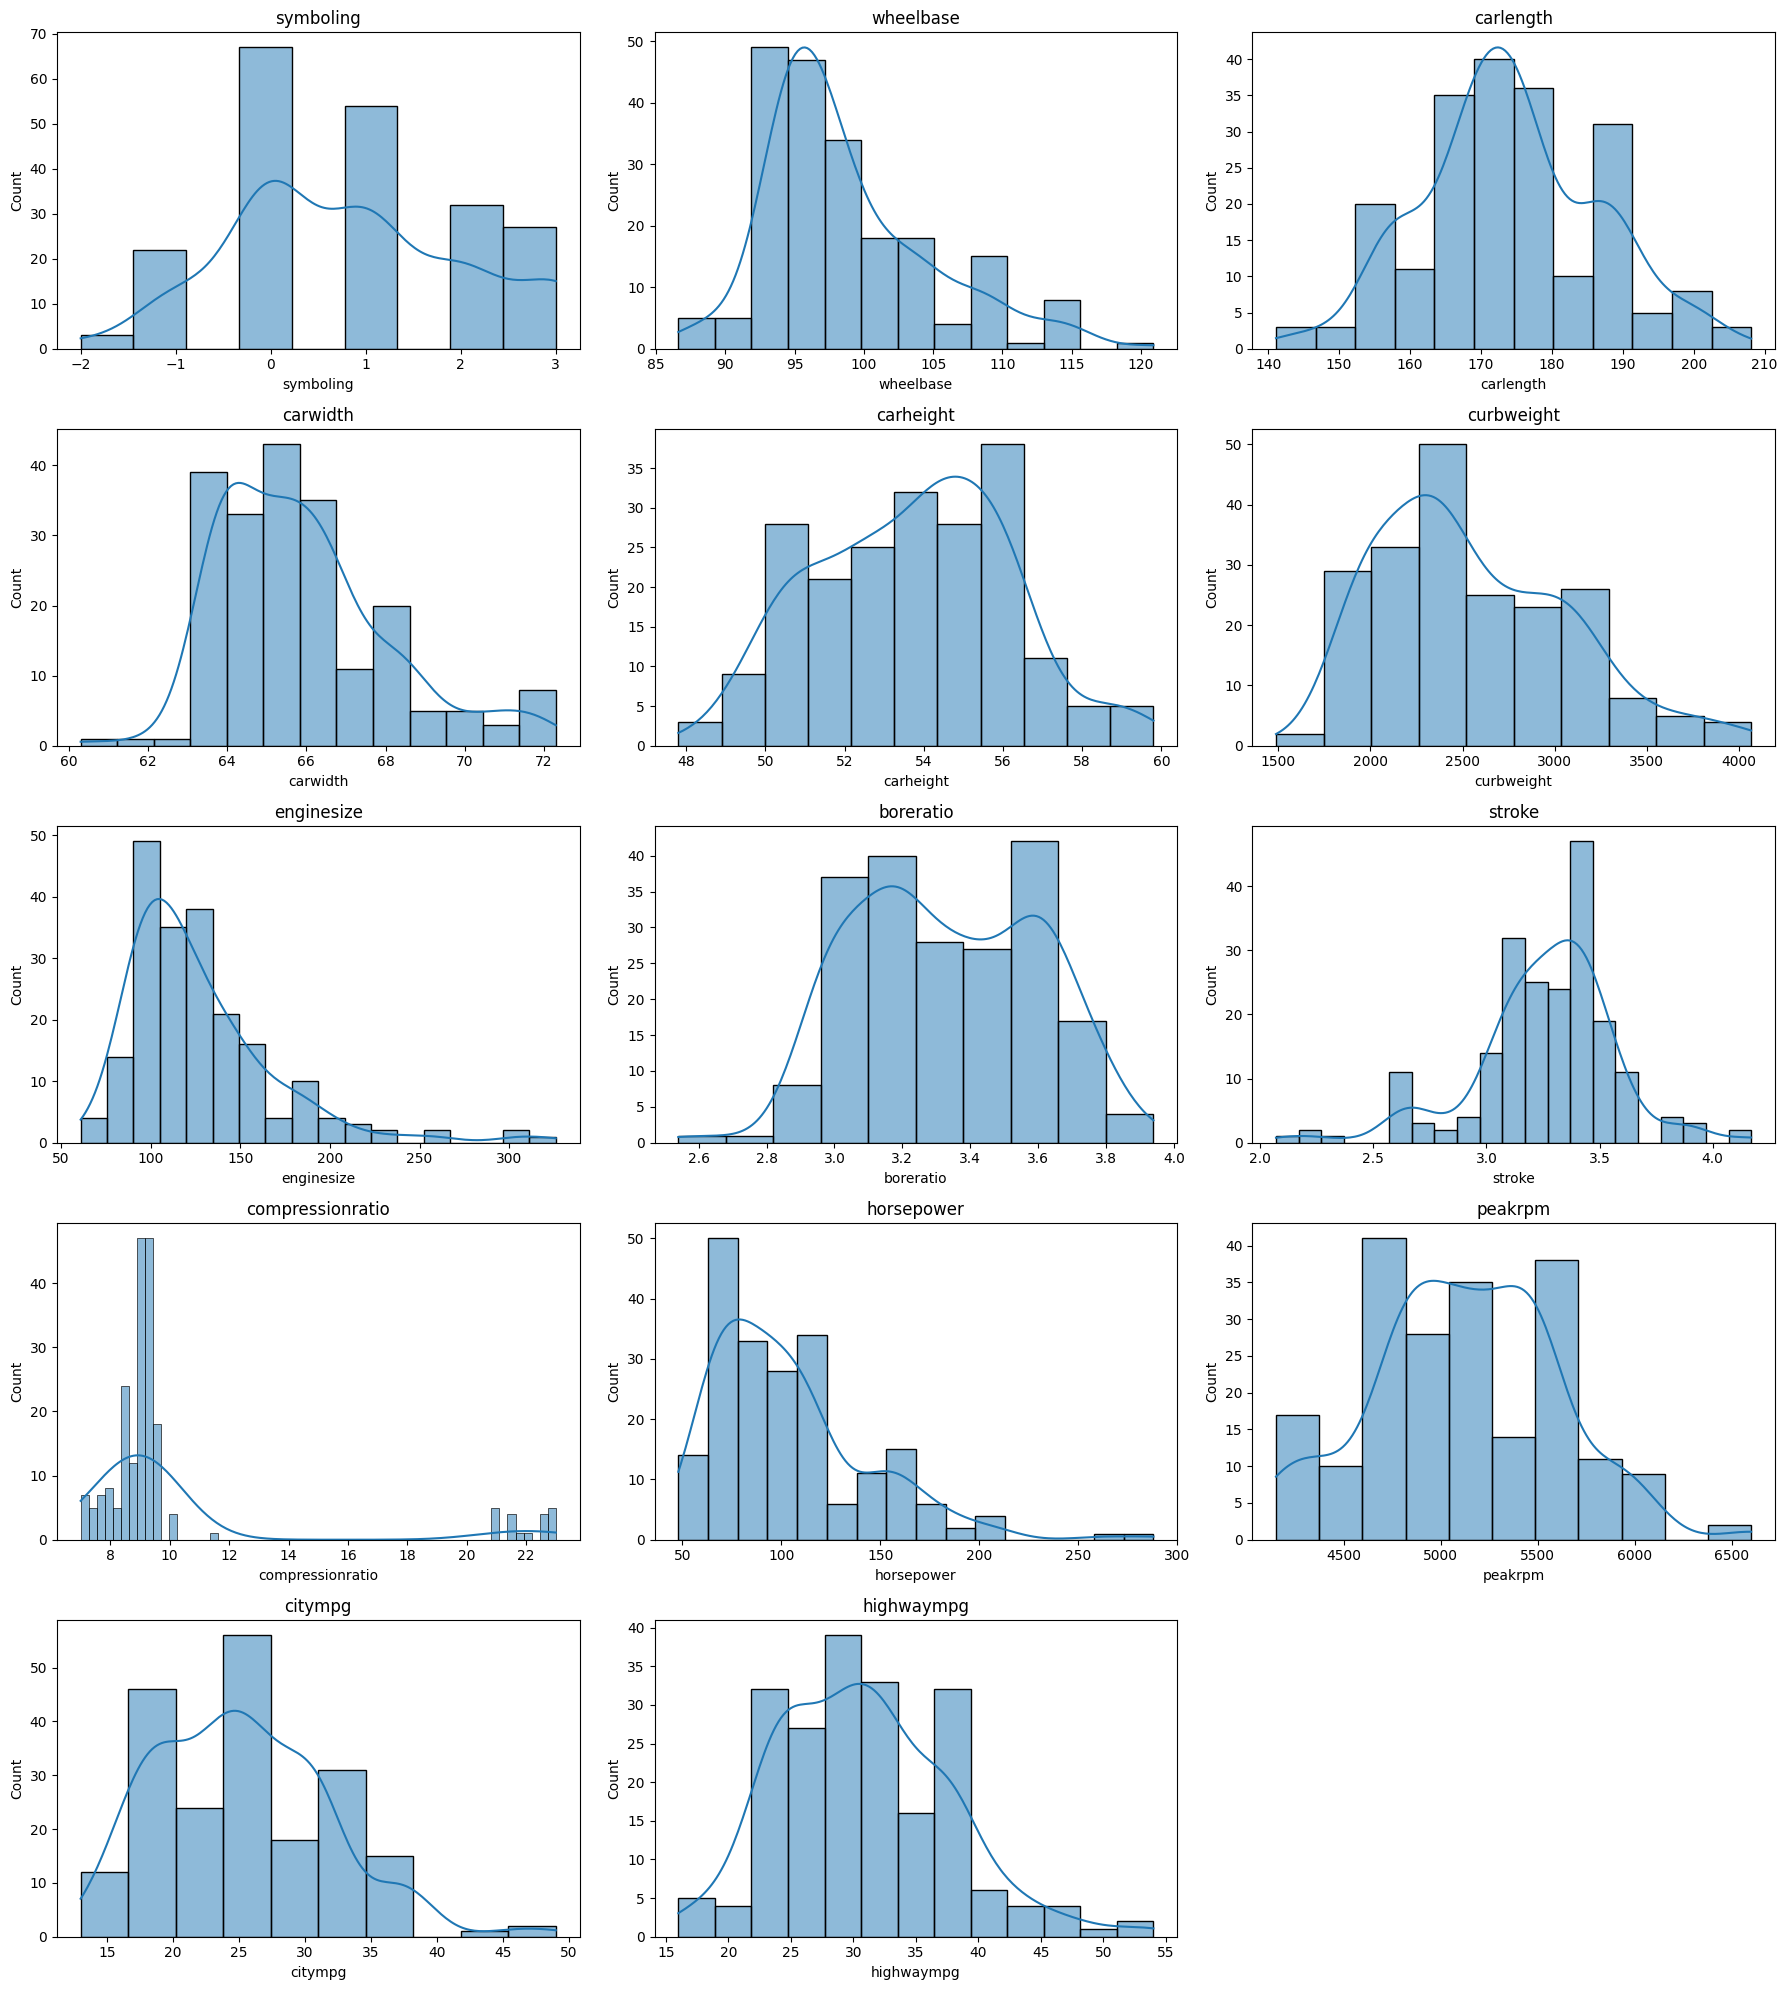

Найбільш асиметричні ознаки:


,skewness
compressionratio,2.610862
enginesize,1.947655
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997
symboling,0.211072


In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove("car_ID")
numeric_cols.remove("price")

print("Числові ознаки:")
print(numeric_cols)

skewness = df[numeric_cols].skew().sort_values(key=abs, ascending=False)

print("\nКоефіцієнти асиметрії:")
display(skewness.to_frame("skewness"))

n = len(numeric_cols)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print("Найбільш асиметричні ознаки:")
display(skewness.head(10).to_frame("skewness"))

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["car_ID", "price"])
y = df["price"]
car_ids = df["car_ID"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    car_ids,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nКількість car_ID у train:", len(id_train))
print("Кількість car_ID у test:", len(id_test))

Train: (164, 24)
Test: (41, 24)

Кількість car_ID у train: 164
Кількість car_ID у test: 41


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [10]:
continuous_cols = [
    col for col in X_train.select_dtypes(include=np.number).columns
    if col != "symboling"
]

outlier_counts = {}

for col in continuous_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_counts[col] = ((X_train[col] < lower) | (X_train[col] > upper)).sum()

outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)

print("Кількість потенційних викидів:")
display(outlier_counts.to_frame("outliers"))
iqr_bounds = {}

for col in continuous_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1

    iqr_bounds[col] = (
        q1 - 1.5 * iqr,
        q3 + 1.5 * iqr
    )
X_train_capped = X_train.copy()
X_test_capped = X_test.copy()

for col, (lower, upper) in iqr_bounds.items():
    X_train_capped[col] = X_train_capped[col].clip(lower, upper)
    X_test_capped[col] = X_test_capped[col].clip(lower, upper)

print("Обробку викидів завершено.")

Кількість потенційних викидів:


,outliers
compressionratio,20
stroke,16
carwidth,10
horsepower,7
enginesize,7
wheelbase,6
peakrpm,2
highwaympg,1
boreratio,1
curbweight,0


Обробку викидів завершено.


## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


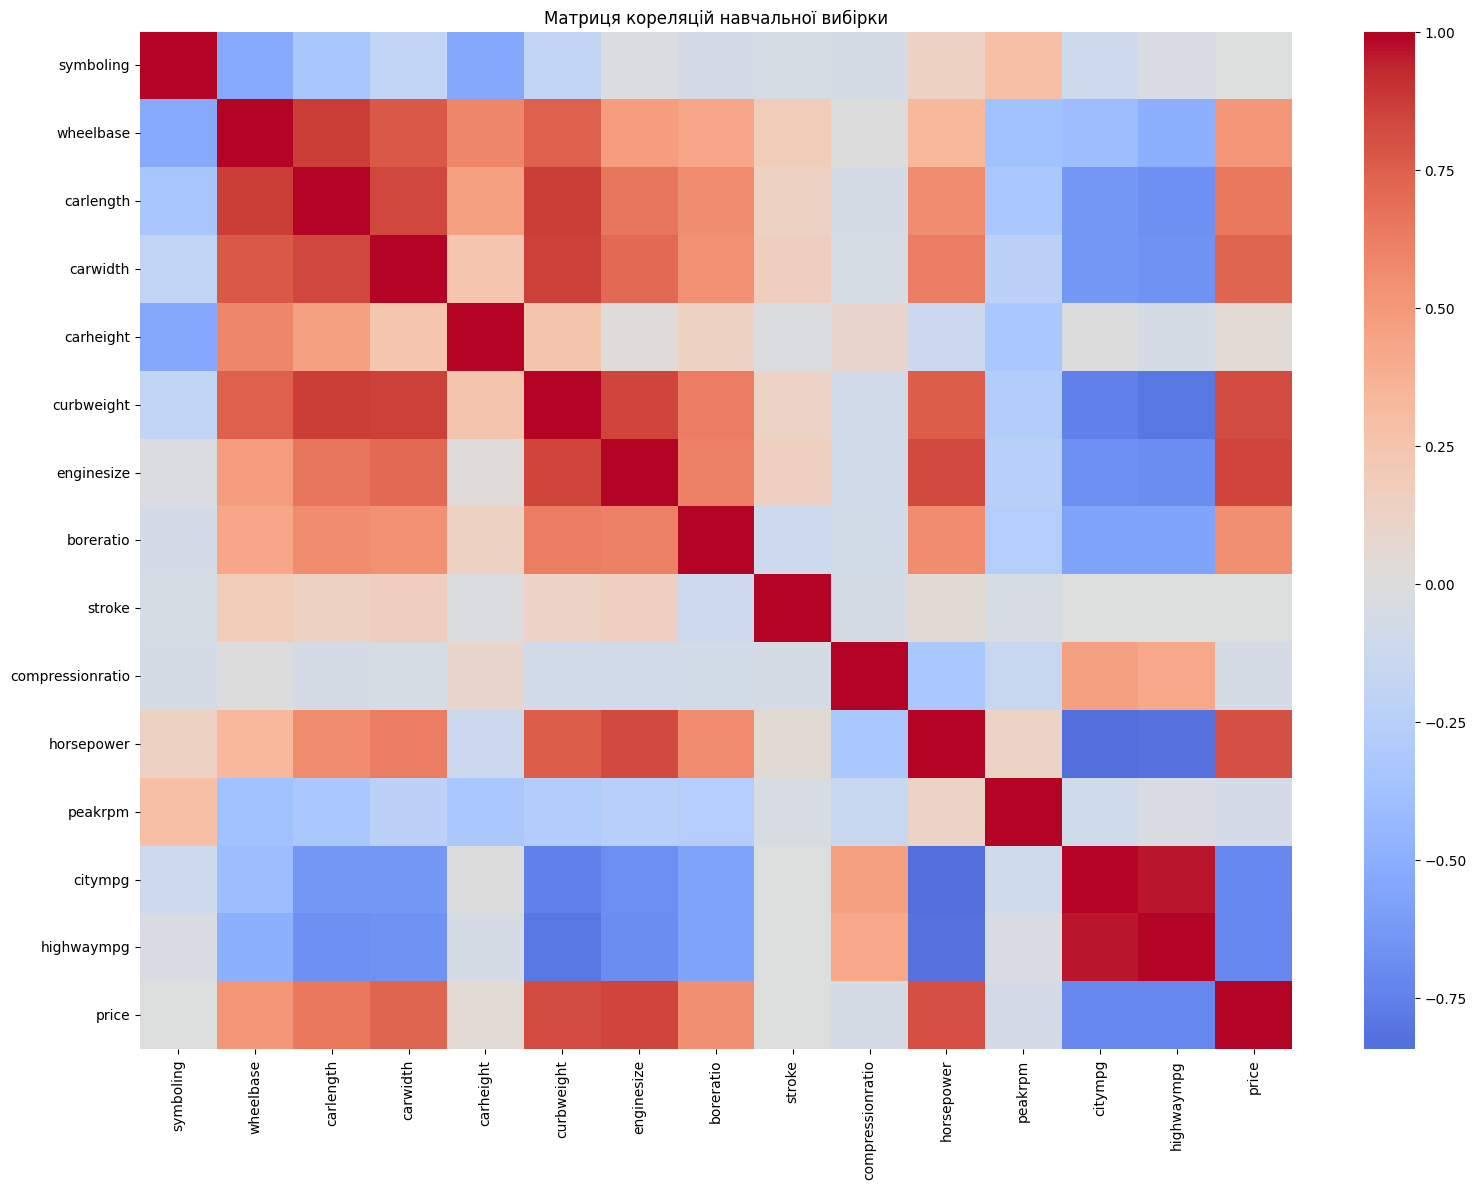

,Ознака 1,Ознака 2,Кореляція
0,wheelbase,carlength,0.867043
1,carlength,curbweight,0.865988
2,carwidth,curbweight,0.858047
3,citympg,highwaympg,0.963620


Ознаки, які видаляються:
['carlength', 'carwidth', 'citympg', 'wheelbase']
Розмір X_train після відбору: (164, 20)
Розмір X_test після відбору: (41, 20)


In [11]:
train_corr = X_train_capped.select_dtypes(include=np.number).copy()
train_corr["price"] = y_train

corr_matrix = train_corr.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Матриця кореляцій навчальної вибірки")
plt.tight_layout()
plt.show()
numeric_for_corr = X_train_capped.select_dtypes(include=np.number).columns

strong_pairs = []

for i in range(len(numeric_for_corr)):
    for j in range(i + 1, len(numeric_for_corr)):
        col1 = numeric_for_corr[i]
        col2 = numeric_for_corr[j]
        r = X_train_capped[[col1, col2]].corr().iloc[0, 1]

        if abs(r) > 0.85:
            strong_pairs.append((col1, col2, r))

strong_pairs_df = pd.DataFrame(
    strong_pairs,
    columns=["Ознака 1", "Ознака 2", "Кореляція"]
)

display(strong_pairs_df)
price_corr = train_corr.corr()["price"].drop("price").abs()

features_to_drop = set()

for col1, col2, r in strong_pairs:
    if price_corr[col1] >= price_corr[col2]:
        features_to_drop.add(col2)
    else:
        features_to_drop.add(col1)

features_to_drop = sorted(features_to_drop)

print("Ознаки, які видаляються:")
print(features_to_drop)
X_train_selected = X_train_capped.drop(columns=features_to_drop)
X_test_selected = X_test_capped.drop(columns=features_to_drop)

print("Розмір X_train після відбору:", X_train_selected.shape)
print("Розмір X_test після відбору:", X_test_selected.shape)

## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [12]:
continuous_cols = [
    col for col in X_train_selected.select_dtypes(include=np.number).columns
    if col != "symboling"
]

symboling_col = ["symboling"]

categorical_cols = X_train_selected.select_dtypes(
    include=["object"]
).columns.tolist()

print("Неперервні числові:")
print(continuous_cols)

print("\nДискретна числова:")
print(symboling_col)

print("\nКатегоріальні:")
print(categorical_cols)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder

continuous_pipeline = Pipeline([
    ("yeo_johnson", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])

symboling_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("continuous", continuous_pipeline, continuous_cols),
    ("symboling", symboling_pipeline, symboling_col),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

Неперервні числові:
['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']

Дискретна числова:
['symboling']

Категоріальні:
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [18]:
X_train_transformed_numeric = X_train_selected[continuous_cols].copy()

yeo = PowerTransformer(method="yeo-johnson", standardize=False)
scaled = StandardScaler()

X_train_yeo = yeo.fit_transform(X_train_transformed_numeric)
X_train_scaled = scaled.fit_transform(X_train_yeo)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=continuous_cols,
    index=X_train_transformed_numeric.index
)

transformed_skewness = X_train_scaled_df.skew()

comparison = pd.DataFrame({
    "Початкова асиметрія": X_train_transformed_numeric.skew(),
    "Після Yeo-Johnson + StandardScaler": transformed_skewness
})

display(comparison)

comparison["Абсолютна початкова"] = comparison["Початкова асиметрія"].abs()
comparison["Абсолютна після"] = comparison["Після Yeo-Johnson + StandardScaler"].abs()

display(
    comparison.sort_values(
        "Абсолютна початкова",
        ascending=False
    ).drop(columns=["Абсолютна початкова", "Абсолютна після"])
)

,Початкова асиметрія,Після Yeo-Johnson + StandardScaler
carheight,0.028154,-0.005170
curbweight,0.712433,0.049894
enginesize,0.962394,0.044834
boreratio,0.062963,-0.005941
stroke,-0.397600,0.015846
compressionratio,0.055710,0.004872
horsepower,0.850735,0.066280
peakrpm,0.039773,-0.003589
highwaympg,0.243761,-0.012188


,Початкова асиметрія,Після Yeo-Johnson + StandardScaler
enginesize,0.962394,0.044834
horsepower,0.850735,0.066280
curbweight,0.712433,0.049894
stroke,-0.397600,0.015846
highwaympg,0.243761,-0.012188
boreratio,0.062963,-0.005941
compressionratio,0.055710,0.004872
peakrpm,0.039773,-0.003589
carheight,0.028154,-0.005170


## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [20]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1, max_iter=10000),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "SVR": SVR(kernel="rbf")
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

for name, pipeline in pipelines.items():
    pipeline.fit(X_train_selected, y_train)

print("Усі моделі працюють.")

Усі моделі працюють.


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [21]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

results = []
predictions = {}

for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test_selected)
    predictions[name] = y_pred

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = np.mean(
        np.abs((y_test - y_pred) / y_test)
    ) * 100

    results.append([
        name,
        r2,
        mae,
        mse,
        mape
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Модель",
        "R²",
        "MAE",
        "MSE",
        "MAPE (%)"
    ]
)

results_df = results_df.sort_values(
    "R²",
    ascending=False
).reset_index(drop=True)

display(results_df)
display(
    results_df.style.format({
        "R²": "{:.4f}",
        "MAE": "{:.2f}",
        "MSE": "{:.2f}",
        "MAPE (%)": "{:.2f}"
    })
)

,Модель,R²,MAE,MSE,MAPE (%)
0,Random Forest,0.950934,1424.397593,3.873485e+06,10.344366
1,Gradient Boosting,0.929565,1684.462050,5.560430e+06,12.590929
2,Ridge Regression,0.795685,2712.775579,1.612943e+07,23.064936
3,Lasso Regression,0.569557,3762.726092,3.398087e+07,26.757884
4,Linear Regression,0.548049,4078.293935,3.567884e+07,29.972536
5,SVR,-0.099660,5696.454036,8.681160e+07,36.024044


,Модель,R²,MAE,MSE,MAPE (%)
0,Random Forest,0.9509,1424.40,3873485.24,10.34
1,Gradient Boosting,0.9296,1684.46,5560429.73,12.59
2,Ridge Regression,0.7957,2712.78,16129429.82,23.06
3,Lasso Regression,0.5696,3762.73,33980866.63,26.76
4,Linear Regression,0.5480,4078.29,35678836.25,29.97
5,SVR,-0.0997,5696.45,86811600.83,36.02


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


Ключовою змінною є price, у якої є неперервне числове значення. Тому прогнозування ціни автомобіля виконується регресією. Класифікаційні моделі, а саме Logistic Regression, призначені для передбачення класів чи категорій, не використовуються для прогнозування неперервної ціни. Тому використано регресійні моделі: Linear Regression, Ridge Regression, Lasso Regression, Random Forest Regressor, Gradient Boosting Regressor та Support Vector Regressor.

## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


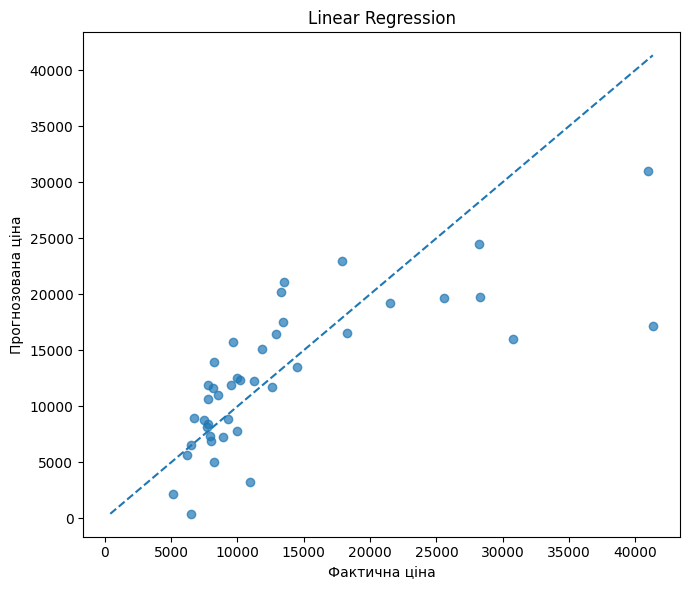

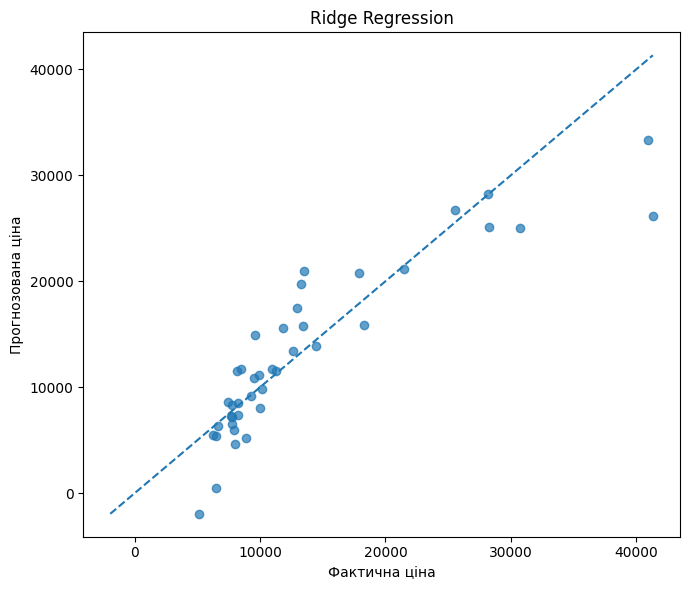

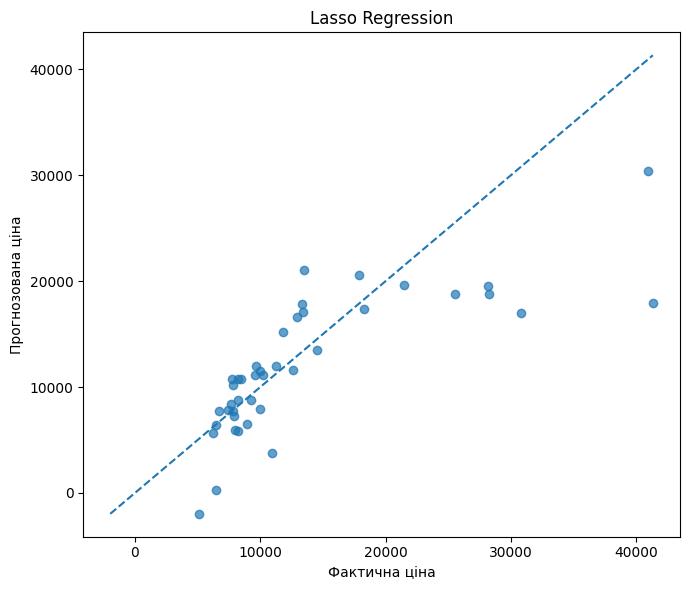

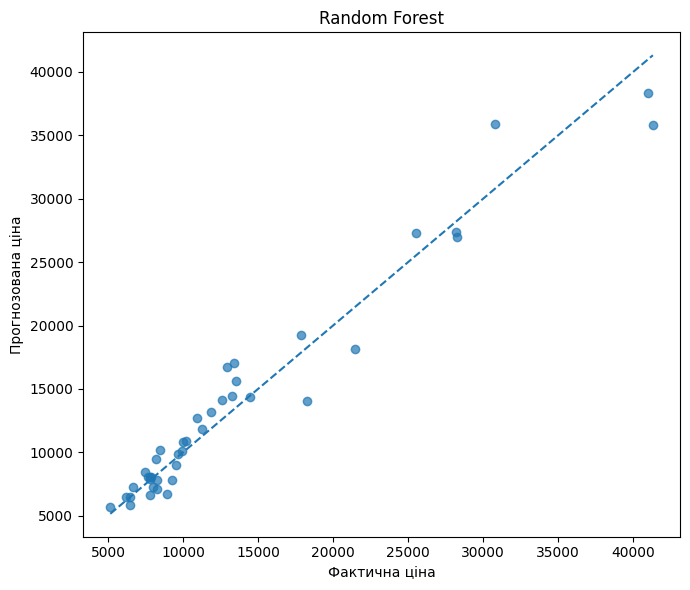

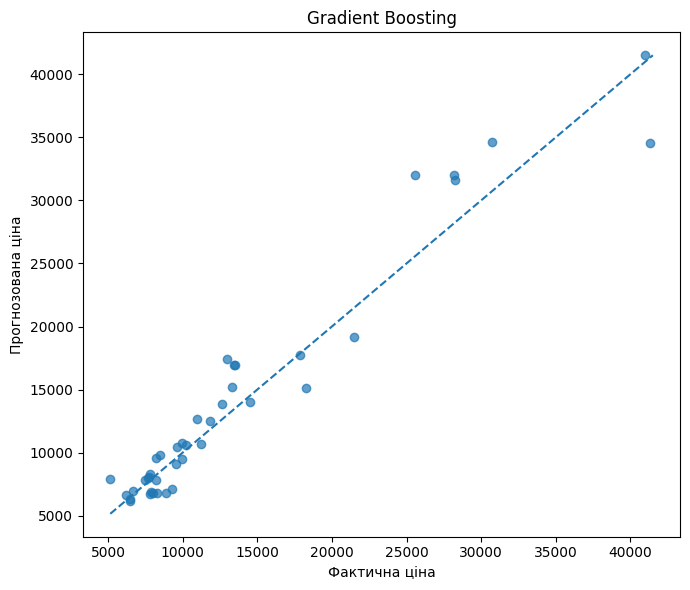

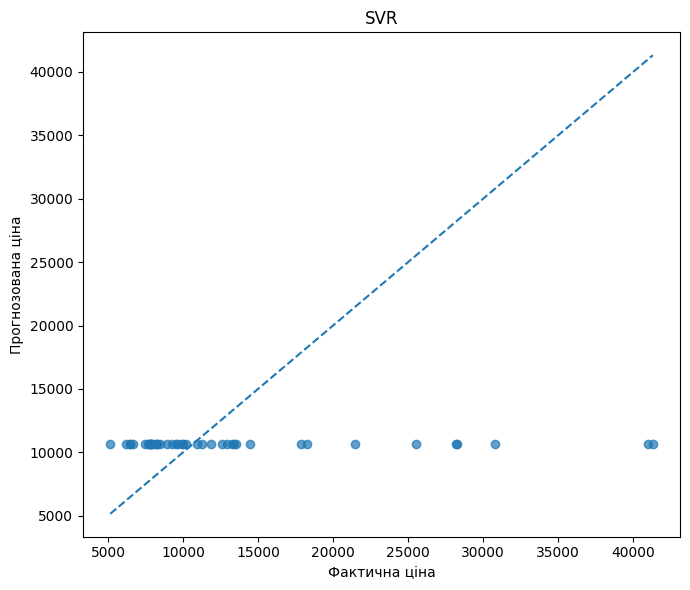

In [22]:
for name, y_pred in predictions.items():
    plt.figure(figsize=(7, 6))

    plt.scatter(y_test, y_pred, alpha=0.7)

    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(name)

    plt.tight_layout()
    plt.show()

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [23]:
rng = np.random.default_rng(42)

sample_indices = rng.choice(
    X_test_selected.index,
    size=10,
    replace=False
)

X_10 = X_test_selected.loc[sample_indices]
y_10 = y_test.loc[sample_indices]
id_10 = id_test.loc[sample_indices]

rf_model = pipelines["Random Forest"]

pred_10 = rf_model.predict(X_10)

prediction_table = pd.DataFrame({
    "car_ID": id_10.values,
    "Фактична ціна": y_10.values,
    "Прогнозована ціна": pred_10
})

prediction_table["Абсолютна помилка"] = (
    prediction_table["Фактична ціна"] -
    prediction_table["Прогнозована ціна"]
).abs()

prediction_table["Абсолютна процентна помилка (%)"] = (
    prediction_table["Абсолютна помилка"] /
    prediction_table["Фактична ціна"]
) * 100

prediction_table = prediction_table.sort_values("car_ID")

display(
    prediction_table.style.format({
        "Фактична ціна": "{:.2f}",
        "Прогнозована ціна": "{:.2f}",
        "Абсолютна помилка": "{:.2f}",
        "Абсолютна процентна помилка (%)": "{:.2f}"
    })
)
print(
    "Середня абсолютна помилка:",
    prediction_table["Абсолютна помилка"].mean()
)

print(
    "Середня абсолютна процентна помилка:",
    prediction_table["Абсолютна процентна помилка (%)"].mean()
)

,car_ID,Фактична ціна,Прогнозована ціна,Абсолютна помилка,Абсолютна процентна помилка (%)
1,17,41315.00,35845.66,5469.34,13.24
5,70,28176.00,27378.19,797.81,2.83
3,99,8249.00,7114.56,1134.44,13.75
2,101,9549.00,9037.97,511.03,5.35
9,121,6229.00,6446.90,217.90,3.50
0,133,11850.00,13192.80,1342.80,11.33
7,147,7463.00,8422.47,959.47,12.86
8,148,10198.00,10871.77,673.77,6.61
4,153,6488.00,6467.80,20.20,0.31
6,196,13415.00,17055.39,3640.39,27.14


Середня абсолютна помилка: 1476.7166666666662
Середня абсолютна процентна помилка: 9.691505497373573


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
